In [65]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("LocalETL")
    # === MEMORY ALLOCATION ===
    .config("spark.driver.memory", "10g")        # main process (driver)
    .config("spark.executor.memory", "10g")      # worker processes (same JVM locally)
    .config("spark.driver.maxResultSize", "2g")  # prevent result collection errors
    
    # === PARALLELISM ===
    .config("spark.driver.cores", "6")           # use 6 out of 8 cores
    .config("spark.executor.cores", "6")
    .config("spark.default.parallelism", "12")   # usually ~2x num_cores for local
    
    # === PERFORMANCE TUNING ===
    .config("spark.sql.shuffle.partitions", "24")  # parallelize shuffles (joins/groupBy)
    .config("spark.memory.fraction", "0.8")        # 80% of JVM heap for Spark execution
    .config("spark.memory.storageFraction", "0.4") # 40% of that for caching
    .config("spark.sql.files.maxPartitionBytes", "128MB")  # ideal partition size for I/O
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")  # fast Pandas conversion
    .config("spark.local.dir", "/tmp/spark-temp")  # local disk space for shuffle spill
    
    # === OPTIONAL LOGGING + CLEANUP ===
    .config("spark.sql.broadcastTimeout", "600")  # allow large table broadcasts
    .config("spark.cleaner.periodicGC.interval", "5min")  # reduce memory leaks
    
    .getOrCreate()
)


In [66]:
from pyspark.sql import functions as F

# --- Example reads ---
transactions_df = spark.read.parquet("data/curated/merchant_transactions/")
consumers_df = spark.read.parquet("data/curated/tbl_consumer/")
fraud_df = spark.read.csv("data/tables/merchant_data/consumer_fraud_probability.csv", header=True, inferSchema=True)
user_df = spark.read.parquet("data/tables/merchant_data/consumer_user_details.parquet")
income_df = spark.read.csv("data/curated/merged_postcode_income.csv", header=True, inferSchema=True)

#Mapping consumer_id to user_id
ctu_df = consumers_df.join(user_df, on="consumer_id", how="left").dropDuplicates(["consumer_id"])

merged_df = (
    transactions_df
    .join(fraud_df, on=["user_id", "order_datetime"], how="left")
    .join(ctu_df, on="user_id", how="left")
    .join(income_df, on="postcode", how="left")

)

merged_df.dropDuplicates(["order_datetime"])
merged_df = merged_df.withColumn("take_rate", F.col("take_rate").cast("float"))


In [67]:
merged_df = merged_df.withColumn("order_day", F.dayofmonth("order_datetime"))
merged_df = merged_df.withColumn("order_month", F.month("order_datetime"))
merged_df = merged_df.withColumn("order_weekday", F.dayofweek("order_datetime"))
merged_df = merged_df.withColumn("order_year", F.year("order_datetime"))

In [68]:
from pyspark.sql.window import Window

window = Window.partitionBy("consumer_id").orderBy("order_datetime")

merged_df = merged_df.withColumn("prev_order_datetime", F.lag("order_datetime").over(window))
merged_df = merged_df.withColumn("days_since_last_order",
                   F.when(F.col("prev_order_datetime").isNotNull(),
                          F.datediff("order_datetime", "prev_order_datetime"))
                   .otherwise(0))

In [69]:
window_consumer = Window.partitionBy("consumer_id")
window_merchant = Window.partitionBy("merchant_abn")

# Consumer-level aggregations
merged_df = merged_df.withColumn("avg_dollar_value_consumer", F.avg("dollar_value").over(window_consumer))
merged_df = merged_df.withColumn("total_transactions_consumer", F.count("dollar_value").over(window_consumer))

# Merchant-level aggregations
merged_df = merged_df.withColumn("total_transactions_merchant", F.count("dollar_value").over(window_merchant))

In [70]:
merged_df = merged_df.withColumn("income_dollar_ratio", F.col("median_total_income_2020") / (F.col("dollar_value") + 1))

In [71]:
merged_df = merged_df.withColumn(
    "fraud_category_label",
    F.when(F.col("fraud_probability") < 10, 0)
     .when(F.col("fraud_probability") < 30, 1)
     .when(F.col("fraud_probability") < 60, 2)
     .otherwise(3)
)



In [72]:

X = merged_df.filter(F.col("fraud_probability").isNotNull()).filter(F.col("income_bin").isNotNull())
Y = merged_df.filter(F.col("fraud_probability").isNull()).filter(F.col("income_bin").isNotNull())
print(X.count())
print(Y.count())

43795


10577277


In [73]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import RegressionEvaluator

In [74]:
# Example features
numeric_features = ["dollar_value", "take_rate",
    "days_since_last_order", "avg_dollar_value_consumer", "total_transactions_consumer",
    "total_transactions_merchant", "income_dollar_ratio"]
categorical_features = ["rev_band", "state", "income_bin", "postcode"]

# Target variable
label = "fraud_probability"

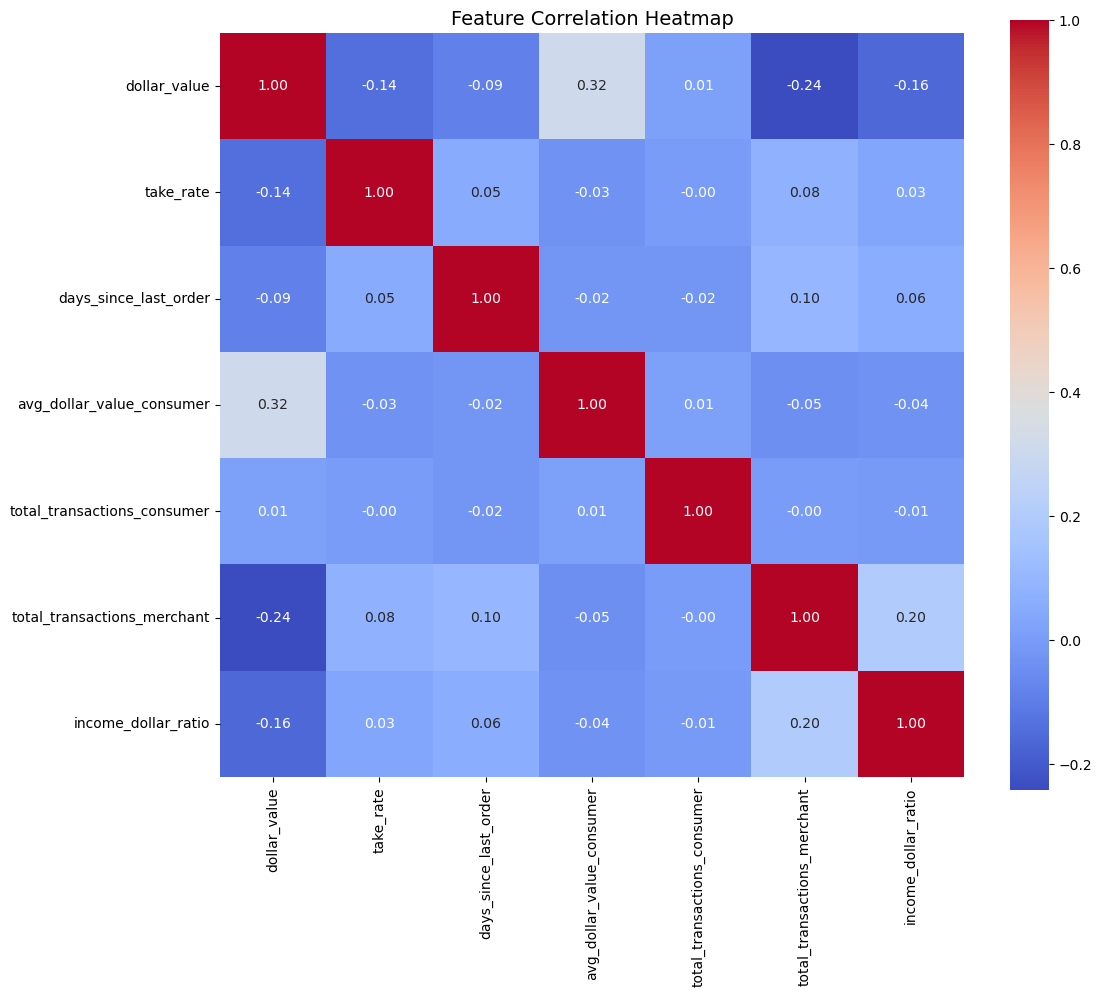

In [75]:
# Convert small sample to pandas (for visualization)
numeric_df = X.select(numeric_features).toPandas()

# Compute correlation matrix
import pandas as pd
corr_matrix = numeric_df.corr(method='pearson')

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=True, fmt=".2f", square=True)
plt.title("Feature Correlation Heatmap", fontsize=14)
plt.show()

In [76]:
# StringIndexer for each categorical feature
indexers = [
    StringIndexer(inputCol=col, outputCol=col + "_idx", handleInvalid="keep")
    for col in categorical_features
]

# OneHotEncoder for each indexed column
encoders = [
    OneHotEncoder(inputCol=col + "_idx", outputCol=col + "_vec")
    for col in categorical_features
]


In [77]:
assembler_inputs = [f + "_vec" for f in categorical_features] + numeric_features

assembler = VectorAssembler(
    inputCols=assembler_inputs,
    outputCol="features"
)

In [36]:
rf = RandomForestRegressor(
    featuresCol="features",
    labelCol=label,
    numTrees=100,
    maxDepth=10,
    seed=67
)

In [37]:
pipeline = Pipeline(stages=indexers + encoders + [assembler, rf])

In [38]:
train_df, test_df = X.randomSplit([0.8, 0.2], seed=67)

model = pipeline.fit(train_df)
predictions = model.transform(test_df)

25/10/06 13:02:15 WARN DAGScheduler: Broadcasting large task binary with size 1207.1 KiB
25/10/06 13:02:33 WARN DAGScheduler: Broadcasting large task binary with size 1917.5 KiB
25/10/06 13:02:51 WARN DAGScheduler: Broadcasting large task binary with size 3.1 MiB
25/10/06 13:03:11 WARN DAGScheduler: Broadcasting large task binary with size 4.9 MiB
25/10/06 13:03:33 WARN DAGScheduler: Broadcasting large task binary with size 7.4 MiB
25/10/06 13:04:03 WARN DAGScheduler: Broadcasting large task binary with size 10.8 MiB
25/10/06 13:04:35 WARN DAGScheduler: Broadcasting large task binary with size 14.7 MiB
25/10/06 13:05:12 WARN DAGScheduler: Broadcasting large task binary with size 19.1 MiB
25/10/06 13:05:53 WARN DAGScheduler: Broadcasting large task binary with size 24.4 MiB


In [39]:
evaluator = RegressionEvaluator(
    labelCol=label,
    predictionCol="prediction",
    metricName="rmse"
)
rmse = evaluator.evaluate(predictions)
r2 = RegressionEvaluator(
    labelCol=label,
    predictionCol="prediction",
    metricName="r2"
).evaluate(predictions)

print(f"RMSE: {rmse:.3f}")
print(f"R²: {r2:.3f}")


RMSE: 8.377
R²: 0.223


In [78]:
from pyspark.ml.classification import RandomForestClassifier

rf_clf = RandomForestClassifier(
    featuresCol="features",
    labelCol="fraud_category_label",
    numTrees=100,
    maxDepth=10,
    seed=67
)

In [79]:
pipeline_clf = Pipeline(stages=indexers + encoders + [assembler, rf_clf])

train_df, test_df = X.randomSplit([0.8, 0.2], seed=67)

class_counts = train_df.groupBy("fraud_category_label").count().collect()
class_counts = {row["fraud_category_label"]: row["count"] for row in class_counts}


min_count = min(class_counts.values())
fractions = {label: min_count / count for label, count in class_counts.items()}

train_balanced_df = train_df.sampleBy(
    "fraud_category_label",
    fractions=fractions,
    seed=42
)



model_clf = pipeline_clf.fit(train_balanced_df)
predictions = model_clf.transform(test_df)

25/10/06 14:01:33 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/10/06 14:05:29 WARN DAGScheduler: Broadcasting large task binary with size 1043.8 KiB


In [64]:
train_df.groupBy("fraud_category_label").count().orderBy("fraud_category_label").show()


25/10/06 13:49:08 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/10/06 13:49:12 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/10/06 13:50:08 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/10/06 13:50:11 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.


+--------------------+-----+
|fraud_category_label|count|
+--------------------+-----+
|                   0|10595|
|                   1|22295|
|                   2| 1831|
|                   3|  305|
+--------------------+-----+



In [ ]:
predictions.groupBy("fraud_category_label", "prediction").count().orderBy("fraud_category_label", "prediction").show()


25/10/06 14:08:20 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/10/06 14:08:21 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.


+--------------------+----------+-----+
|fraud_category_label|prediction|count|
+--------------------+----------+-----+
|                   0|       0.0| 2170|
|                   0|       1.0|  274|
|                   0|       2.0|    7|
|                   0|       3.0|  133|
|                   1|       0.0| 3925|
|                   1|       1.0| 1226|
|                   1|       2.0|  201|
|                   1|       3.0|  288|
|                   2|       0.0|  265|
|                   2|       1.0|   25|
|                   2|       2.0|   97|
|                   2|       3.0|   73|
|                   3|       0.0|   35|
|                   3|       2.0|    4|
|                   3|       3.0|   46|
+--------------------+----------+-----+



25/10/07 15:09:22 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 1259819 ms exceeds timeout 120000 ms
25/10/07 15:09:22 WARN SparkContext: Killing executors is not supported by current scheduler.
25/10/07 15:09:22 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$